# DS2002 Lab — Exploring Data Visualizations with Python

## Overview
In this lab, you will work with a retail sales CSV and experiment with several plotting libraries in Python.

You will learn how to:
- load a CSV into a pandas DataFrame,
- inspect the structure of a dataset,
- summarize data before plotting,
- build visualizations with **matplotlib**, **seaborn**, and **plotly express**,
- create a **heatmap** and a **word cloud**,
- explore how changing a plot changes the story it tells.

This lab is designed to be **hands-on**.  
You should run cells, inspect the output, and then modify the plotting code to see what changes.

---

## Lab mindset
Do not just run each cell and move on.

For each section:
1. read the explanation,
2. run the code,
3. change one or two parameters,
4. observe what changes,
5. answer the short reflection prompt.

That is where the learning happens.


## Part 0 — Imports

### What this cell does
This cell imports the libraries we need.

- **pandas** for reading and organizing tabular data
- **matplotlib** for core charting
- **seaborn** for easier statistical plots
- **plotly express** for interactive plots
- **os** for finding the CSV file in Kaggle
- **WordCloud** for a text-based visualization

### What to notice
Some of these libraries are used for analysis, and some are used only for plotting.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

try:
    from wordcloud import WordCloud
except ImportError:
    !pip install wordcloud -q
    from wordcloud import WordCloud

%matplotlib inline

## Part 1 — Load the CSV

### What this cell does
This cell tries to find the first CSV file under `/kaggle/input`.  
That makes the notebook easier to run in Kaggle without hardcoding the path.

If you are running this notebook outside Kaggle, you can replace the path with a local filename.

### What to notice
A common beginner problem is not knowing where the file actually lives.  
This cell helps remove that problem so you can focus on the analysis.


In [3]:
csv_path = None

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if filename.endswith(".csv"):
            csv_path = os.path.join(dirname, filename)
            break
    if csv_path:
        break

print("CSV path found:", csv_path)

df = pd.read_csv(csv_path)
df.head()

CSV path found: /kaggle/input/datasets/natekim16/labdata/ds2002_walmart_clean_sales.csv


,transaction_id,date,store_id,region,category,product,storm_phase,units_sold,unit_price,revenue
0,T100000,2025-09-29,ST004,South,Breakfast Foods,Instant Oatmeal,Normal,16,3.99,63.84
1,T100001,2025-09-03,ST005,South,Breakfast Foods,Instant Oatmeal,Watch,11,3.99,43.89
2,T100002,2025-09-23,ST003,South,Family & Leisure,Playing Cards,Normal,7,2.99,20.93
3,T100003,2025-08-25,ST007,Southeast,Beverages,Orange Juice,Watch,18,4.19,75.42
4,T100004,2025-09-24,ST007,Southeast,Family & Leisure,Playing Cards,Normal,7,2.99,20.93


## Part 2 — Inspect the dataset

### What this cell does
These cells help you understand the dataset before making any plots.

We check:
- shape,
- column names,
- data types,
- missing values,
- summary statistics.

### Why this matters
A chart is only as good as your understanding of the data behind it.


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (1000, 10)

Columns:
['transaction_id', 'date', 'store_id', 'region', 'category', 'product', 'storm_phase', 'units_sold', 'unit_price', 'revenue']

Data types:
transaction_id     object
date               object
store_id           object
region             object
category           object
product            object
storm_phase        object
units_sold          int64
unit_price        float64
revenue           float64
dtype: object


In [5]:
df.isnull().sum()

transaction_id    0
date              0
store_id          0
region            0
category          0
product           0
storm_phase       0
units_sold        0
unit_price        0
revenue           0
dtype: int64

In [6]:
df.select_dtypes(include='number').describe()


,units_sold,unit_price,revenue
count,1000.000000,1000.000000,1000.000000
mean,14.935000,6.835810,87.836090
std,7.367568,4.901359,54.373168
min,1.000000,2.290000,7.980000
25%,10.000000,3.490000,48.860000
50%,14.000000,4.390000,73.185000
75%,19.000000,9.290000,112.410000
max,46.000000,19.990000,359.820000


### Try it yourself
Answer these questions before moving on:
1. How many rows are in the dataset? 1000
2. Which columns are numeric? 3, one integer, 2 floats
3. Which columns are categorical? transaction_id, date, store_id, region, category, product, storm_phase  
4. What columns seem likely to be useful for charts? category, region, and storm_phase for grouping/comparing. units_sold and revenue for numeric values


## Part 3 — Prepare the data for plotting

### What this cell does
Many charts work better on summarized data than on raw transactional rows.

Here we:
- convert `date` to datetime,
- create a summary by category,
- create a summary by date.

### Why this matters
If you do not summarize data when needed, your plot may be cluttered or misleading.


In [31]:
### df["date"] = pd.to_datetime(df["date"])

category_summary = (
    df.groupby("category", as_index=False)
      .agg(
          total_units_sold=("units_sold", "sum"),
          average_unit_price=("unit_price", "mean"),
          total_revenue=("revenue", "sum")
      )
      .sort_values("total_units_sold", ascending=False)
)


daily_sales_units_sold = (
    df.groupby("date", as_index=False)["units_sold"]
      .sum()
      .sort_values("date")
)
daily_sales_unit_price = df.groupby("date", as_index=False)["unit_price"].sum().sort_values("date")

df["week"] = df["date"].dt.to_period("W").dt.start_time

weekly_sales_units_sold = df.groupby("week", as_index=False)["units_sold"].sum()
weekly_sales_units_price = df.groupby("week", as_index=False)["unit_price"].sum()



category_summary.head()

,category,total_units_sold,average_unit_price,total_revenue
0,Beverages,4764,3.990000,19912.16
1,Breakfast Foods,3407,4.189152,14015.67
4,Snacks,2887,3.861667,11141.53
3,Household,2050,10.374118,21037.00
2,Family & Leisure,1827,11.930639,21729.73


## 1. * Part 4 — Bar chart with matplotlib

### What this cell does
This chart compares total units sold across categories.

### Why this chart type fits
Bar charts are good for comparing **categories**.

### What to experiment with
After you run this cell, try changing:
- the figure size,
- the title,
- the y-axis variable,
- the sort order in `category_summary`.


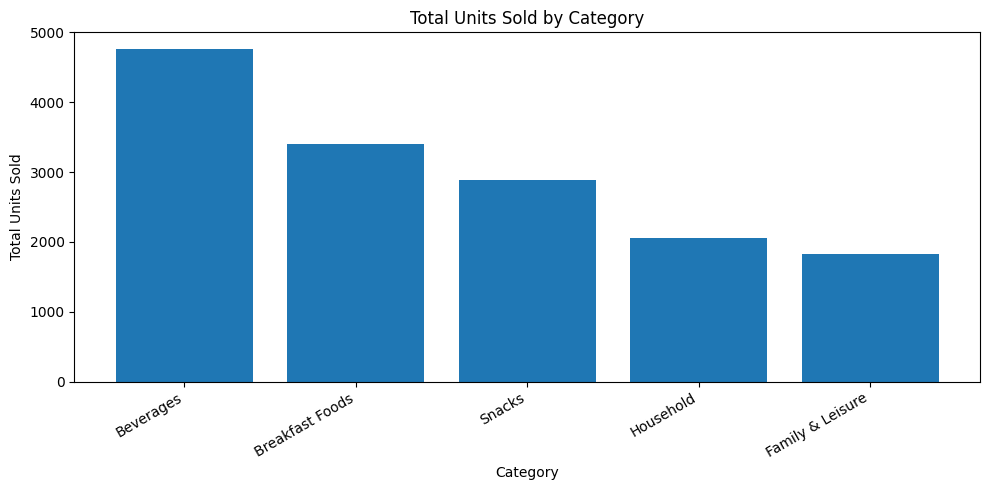

In [32]:
plt.figure(figsize=(10, 5))
plt.bar(category_summary["category"], category_summary["total_units_sold"])
plt.title("Total Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

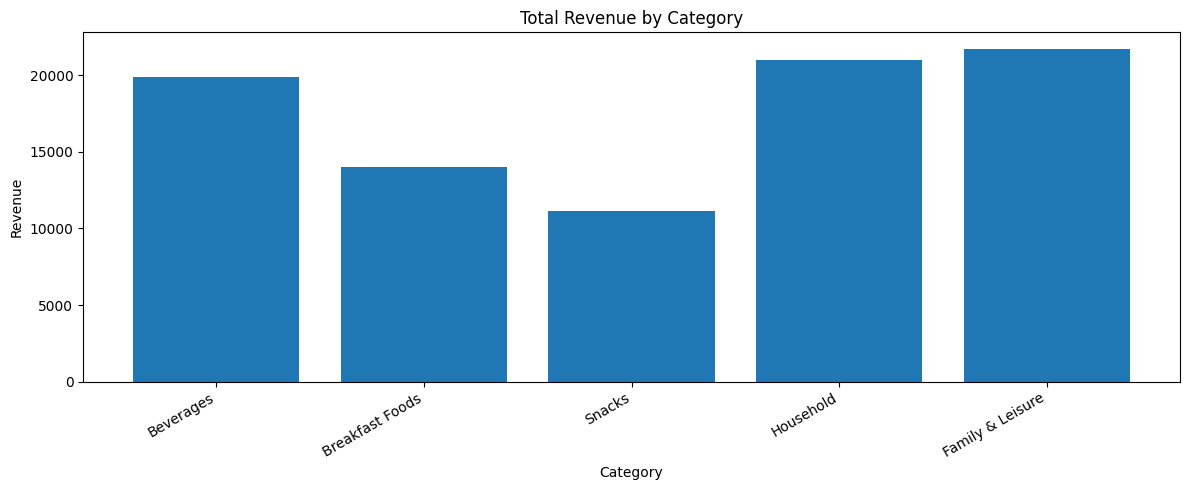

In [33]:
plt.figure(figsize=(12, 5))
plt.bar(category_summary["category"], category_summary["total_revenue"])
plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

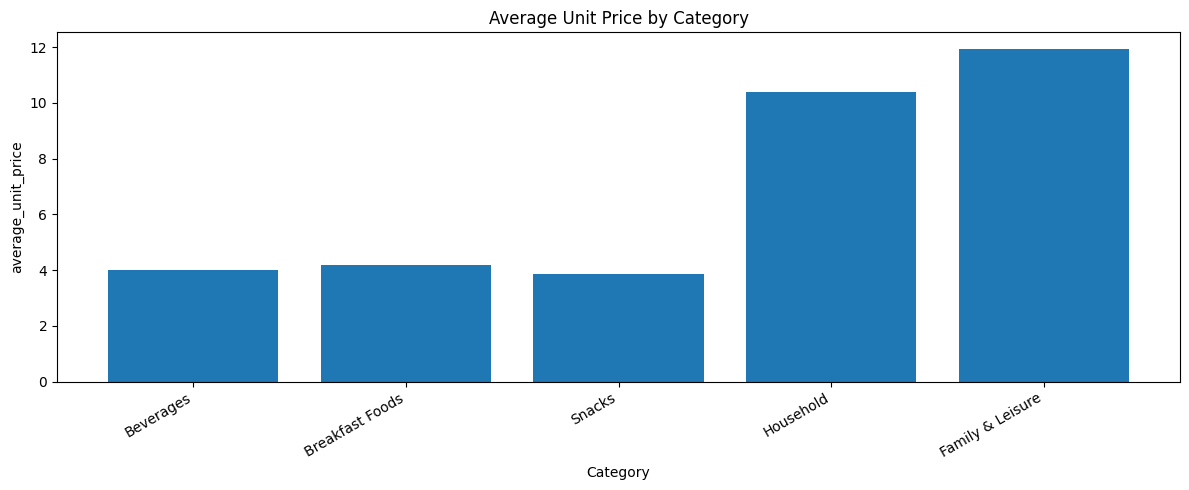

In [34]:
plt.figure(figsize=(12, 5))
plt.bar(category_summary["category"], category_summary["average_unit_price"])
plt.title("Average Unit Price by Category")
plt.xlabel("Category")
plt.ylabel("average_unit_price")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Reflection
- Which category sold the most? Beverages, but Family & Leisure made the most revenue
- Would this chart still work if there were 50 categories? Yes, but it wouldn't be very pretty
- What happens if you plot `average_unit_price` instead of `total_units_sold`? The average unit price of Family & Leisure and Household items are much more expensive than consumables


## Part 5 — Line chart with matplotlib

### What this cell does
This chart shows daily units sold over time.

### Why this chart type fits
Line charts are useful for showing **change across time**.

### What to experiment with
Try changing:
- the plotted variable,
- the line width,
- the date aggregation,
- the filtering before plotting.


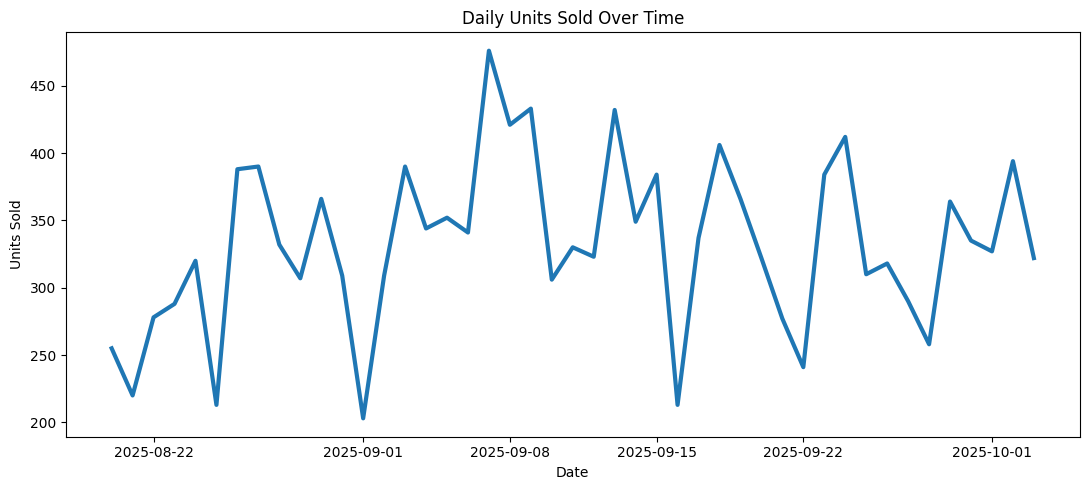

In [36]:
plt.figure(figsize=(11, 5))
plt.plot(daily_sales_units_sold["date"], daily_sales_units_sold["units_sold"], linewidth=3)
plt.title("Daily Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

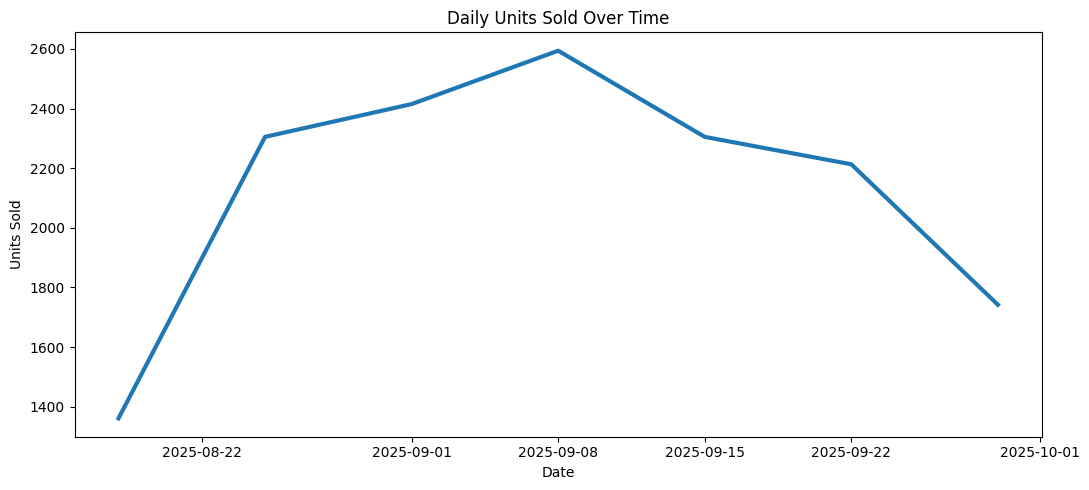

In [38]:
plt.figure(figsize=(11, 5))
plt.plot(weekly_sales_units_sold["week"], weekly_sales_units_sold["units_sold"], linewidth=3)
plt.title("Daily Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

### Reflection
- Does the time trend look smooth or jumpy? days were jumpy, weeks were not. weekly smoother because it's averaging across more data.
- What story does this chart tell? prices peaked in 2025-09-08
- Would a bar chart be better or worse here? worse because you can't see trends as well as line charts.


## Part 6 — Histogram with matplotlib

### What this cell does
A histogram shows how a numeric variable is distributed.

### Why this chart type fits
Use a histogram when you want to understand the **spread** of a variable.

### What to experiment with
Change:
- the number of bins,
- the variable being plotted,
- the figure size.


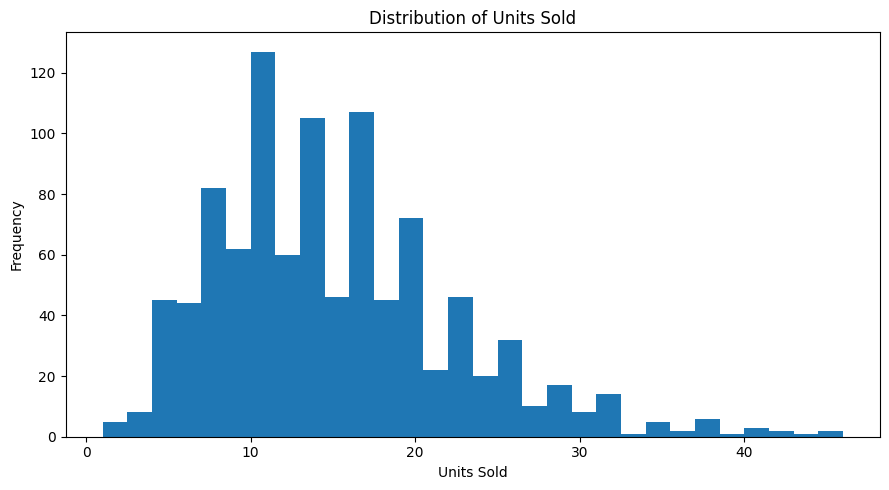

In [43]:
plt.figure(figsize=(9, 5))
plt.hist(df["units_sold"], bins=30)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

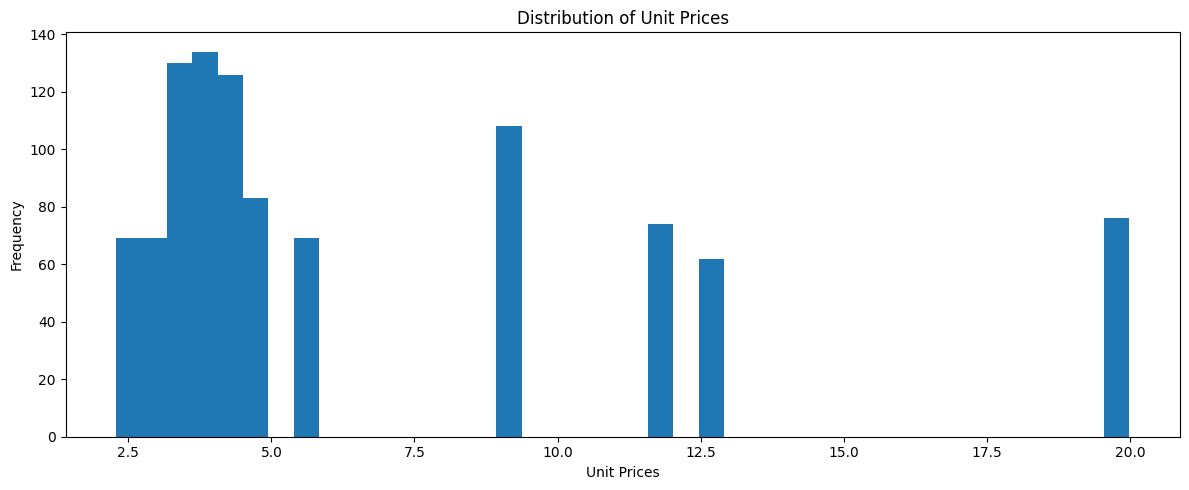

In [42]:
plt.figure(figsize=(12, 5))
plt.hist(df["unit_price"], bins=40)
plt.title("Distribution of Unit Prices")
plt.xlabel("Unit Prices")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Reflection
- Are most transaction rows low, medium, or high in units sold? medium, distribution peaks at 10-12 ish
- What changes when you increase the number of bins? more granular bars, fluctuations become more visible
- Does the histogram reveal any unusual values? small distribution of 40+ units sold


## Part 7 — Scatter plot with matplotlib

### What this cell does
This plot compares two numeric variables: `units_sold` and `revenue`.

### Why this chart type fits
Scatter plots help show **relationships** between numeric variables.

### What to experiment with
Try changing:
- the x and y variables,
- `alpha`,
- the size of the plot.


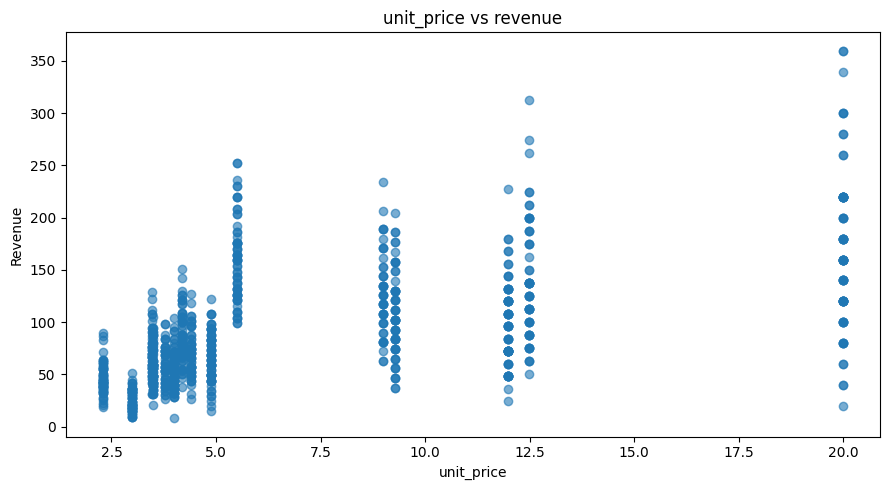

In [51]:
plt.figure(figsize=(9, 5))
plt.scatter(df["unit_price"], df["revenue"], alpha=0.6)
plt.title("unit_price vs revenue")
plt.xlabel("unit_price")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

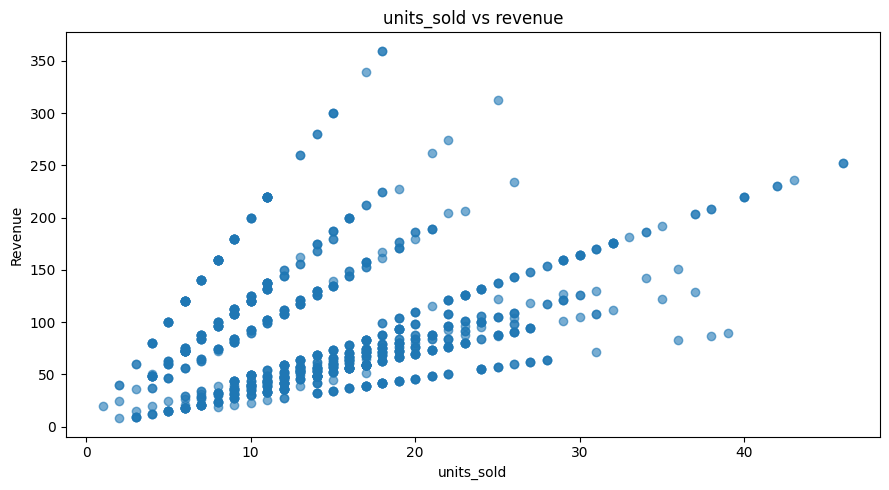

In [48]:
plt.figure(figsize=(9, 5))
plt.scatter(df["units_sold"], df["revenue"], alpha=0.6)
plt.title("units_sold vs revenue")
plt.xlabel("units_sold")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Reflection
- Does revenue generally rise as units sold rises? yes, there's a strong positive relationship
- Why is that relationship expected here? the more units you sell the more revenue you make
- What other numeric pair would be interesting to compare? unit_price x revenue to see if higher priced units make more revenue or not

## Part 8 — Seaborn: faster category plots

### What this cell does
This section recreates some charts with seaborn.

### Why use seaborn
Seaborn often makes grouped and statistical plots easier to build and easier to read.


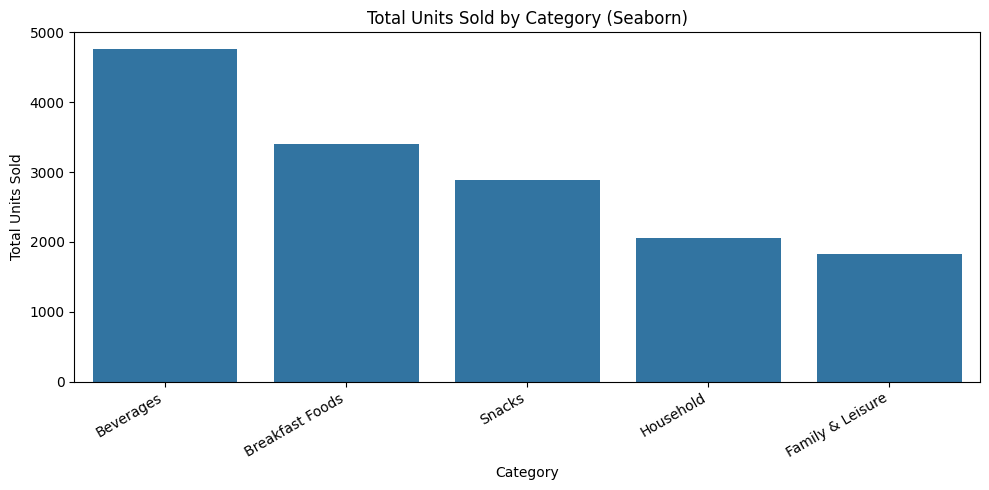

In [22]:
plt.figure(figsize=(10, 5))
sns.barplot(data=category_summary, x="category", y="total_units_sold")
plt.title("Total Units Sold by Category (Seaborn)")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

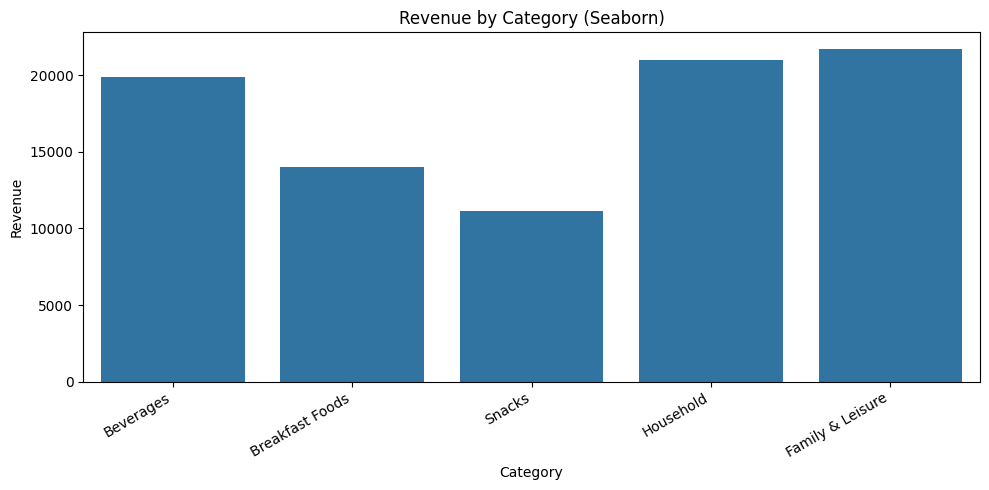

In [54]:
plt.figure(figsize=(10, 5))
sns.barplot(data=category_summary, x="category", y="total_revenue")
plt.title("Revenue by Category (Seaborn)")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

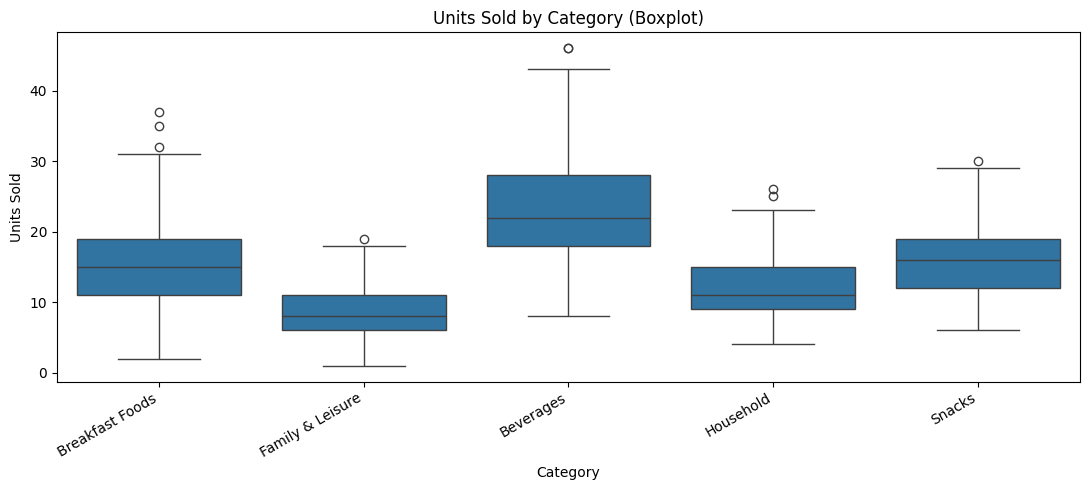

In [23]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="category", y="units_sold")
plt.title("Units Sold by Category (Boxplot)")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

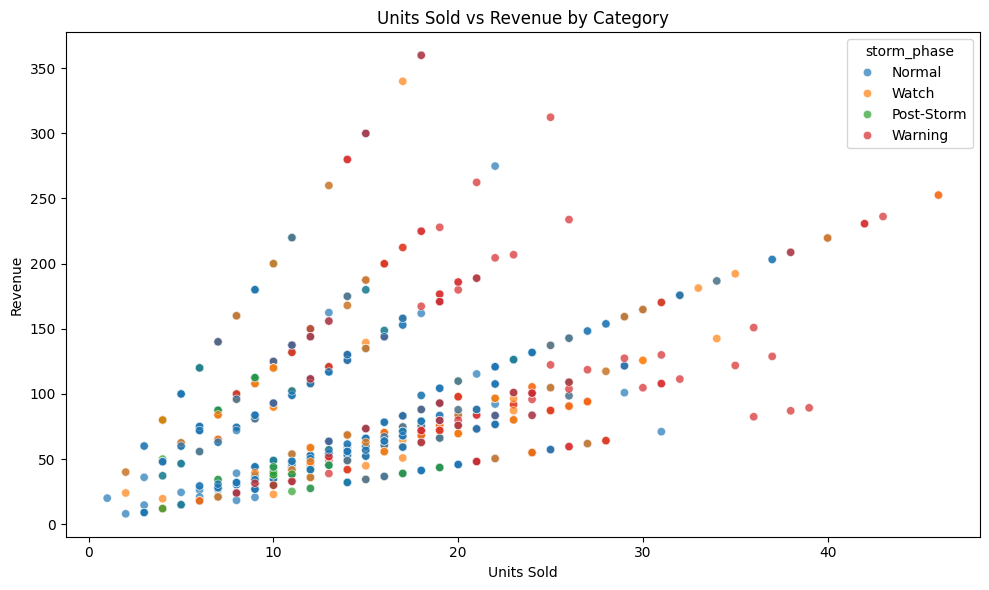

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="units_sold", y="revenue", hue="storm_phase", alpha=0.7)
plt.title("Units Sold vs Revenue by Category")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Try it yourself
Modify one of the seaborn charts to answer one of these questions:
1. Which category has the most variable `units_sold` values? beverages, goes from 10 to upwards of 45 ish
2. Do some categories appear to have consistently higher revenue? Family & leasure, beverages, and household.
3. What happens if you change `hue="category"` to `hue="storm_phase"`? then we can see patterns with the storm phases instead of categories


## Part 9 — Plotly Express: interactive charts

### What this cell does
Plotly Express creates interactive charts that you can hover over.

### Why this is useful
Interactive charts help with exploration because you can inspect exact values without adding labels to everything.


In [56]:
revenue_summary = (
    df.groupby("category", as_index=False)["revenue"]
      .sum()
      .sort_values("revenue", ascending=False)
)

fig = px.bar(
    revenue_summary,
    x="category",
    y="revenue",
    title="Total Revenue by Category (Plotly Express)"
)
fig.show()

In [26]:
fig = px.scatter(
    df,
    x="units_sold",
    y="revenue",
    color="storm_phase",
    hover_data=["product", "store_id", "region"],
    title="Units Sold vs Revenue by Storm Phase"
)
fig.show()

### Reflection
- What is easier to explore in Plotly than in matplotlib? You can zoom in and out about specific data points. If there's a large cluster of data points, you can zoom in to see what's actually happening
- When would an interactive chart be helpful? I think it would be helpful when there's a large cluster of data points
- When is interactivity unnecessary? When a chart is going to be printed out or when you're just sharing a static image of a chart


## Part 10 — Heatmap

### What this cell does
A heatmap can show intensity in a table-like structure.

Here we create a pivot table:
- rows = category
- columns = storm phase
- values = total units sold

### Why this matters
This lets you quickly compare which categories spike under different storm conditions.


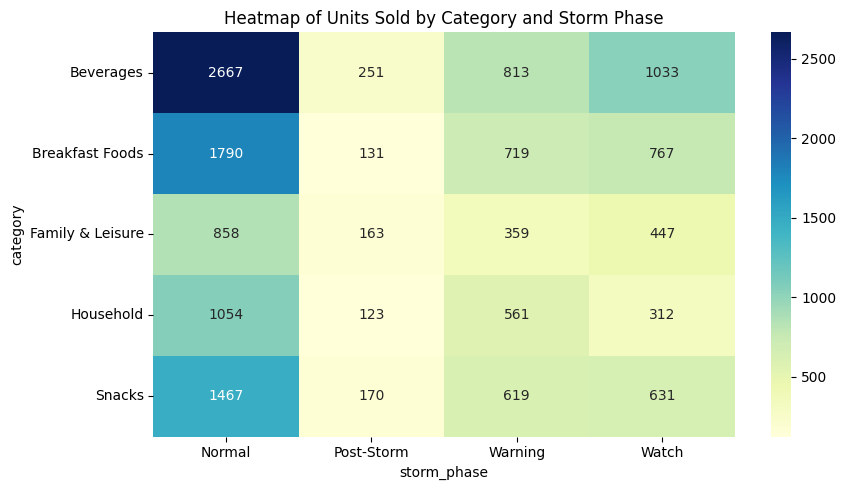

In [27]:
heatmap_data = pd.pivot_table(
    df,
    values="units_sold",
    index="category",
    columns="storm_phase",
    aggfunc="sum"
)

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap of Units Sold by Category and Storm Phase")
plt.tight_layout()
plt.show()

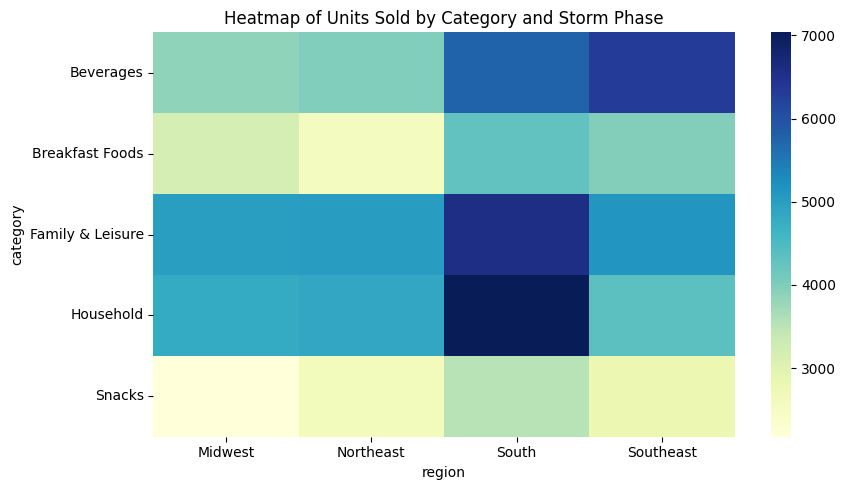

In [57]:
heatmap_data = pd.pivot_table(
    df,
    values="revenue",
    index="category",
    columns="region",
    aggfunc="sum"
)

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=False, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap of Units Sold by Category and Storm Phase")
plt.tight_layout()
plt.show()

### Try it yourself
Change one thing:
- use `revenue` instead of `units_sold`,
- use `region` instead of `storm_phase`,
- remove `annot=True` and see how readability changes.


## Part 11 — Word cloud

### What this cell does
A word cloud displays text values, with more frequent words shown larger.

Here, we build a word cloud using product names weighted by total units sold.

### Why this is interesting
This is a very different kind of chart.  
It is more playful and less precise than a bar chart, but it can still help reveal dominant products.


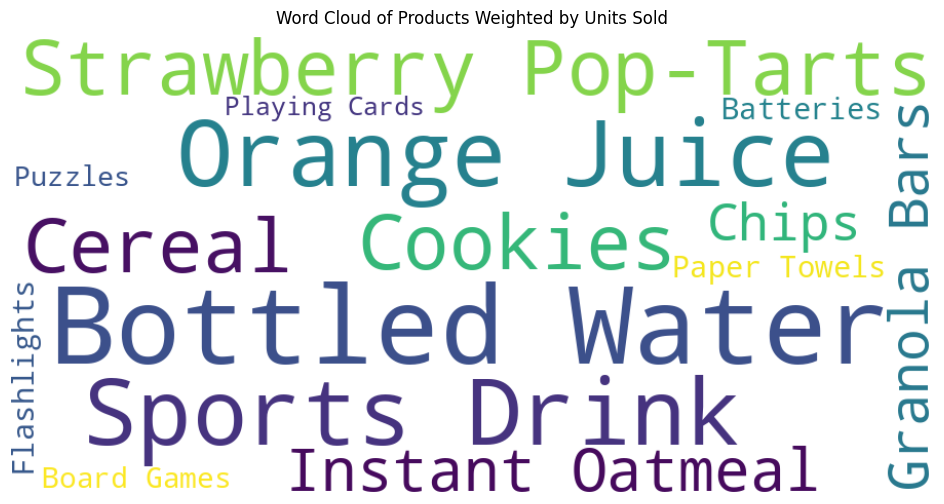

In [28]:
product_totals = df.groupby("product")["units_sold"].sum().to_dict()

wc = WordCloud(width=900, height=450, background_color="white")
wc.generate_from_frequencies(product_totals)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Products Weighted by Units Sold")
plt.show()

### Reflection
- Which products stand out the most? bottled water
- What information is easier to see in a bar chart than in a word cloud? exact values and rankings. Hard to tell if ornage Juice is bigger than sports drink. 
- When might you use this kind of chart in a presentation? it's very eye-catching and conveys information very easily


## Part 12 — Optional map extension

### What this section does
Your current dataset does not include latitude and longitude.

To make a simple map, this cell creates a small synthetic store location lookup and merges it into the dataset.
This is not meant to be perfect geography.  
It is meant to show how a map visualization works.

### Why this is useful
Maps are good when location matters and you want to compare geography directly.


In [29]:
store_locations = pd.DataFrame({
    "store_id": ["ST001","ST002","ST003","ST004","ST005","ST006","ST007","ST008","ST009","ST010",
                 "ST011","ST012","ST013","ST014","ST015","ST016","ST017","ST018","ST019","ST020"],
    "city": ["Houston","Dallas","Atlanta","Miami","New Orleans","Charlotte","Orlando","Tampa","Nashville","Jacksonville",
             "Chicago","Detroit","Columbus","Indianapolis","Milwaukee","Boston","Newark","Buffalo","Pittsburgh","Providence"],
    "state": ["TX","TX","GA","FL","LA","NC","FL","FL","TN","FL",
              "IL","MI","OH","IN","WI","MA","NJ","NY","PA","RI"],
    "latitude": [29.7604,32.7767,33.7490,25.7617,29.9511,35.2271,28.5383,27.9506,36.1627,30.3322,
                 41.8781,42.3314,39.9612,39.7684,43.0389,42.3601,40.7357,42.8864,40.4406,41.8240],
    "longitude": [-95.3698,-96.7970,-84.3880,-80.1918,-90.0715,-80.8431,-81.3792,-82.4572,-86.7816,-81.6557,
                  -87.6298,-83.0458,-82.9988,-86.1581,-87.9065,-71.0589,-74.1724,-78.8784,-79.9959,-71.4128]
})

df_map = df.merge(store_locations, on="store_id", how="left")

store_revenue_map = (
    df_map.groupby(["store_id", "city", "state", "latitude", "longitude"], as_index=False)["revenue"]
          .sum()
)

store_revenue_map.head()

,store_id,city,state,latitude,longitude,revenue
0,ST001,Houston,TX,29.7604,-95.3698,3608.89
1,ST002,Dallas,TX,32.7767,-96.7970,4779.27
2,ST003,Atlanta,GA,33.7490,-84.3880,6972.18
3,ST004,Miami,FL,25.7617,-80.1918,5793.41
4,ST005,New Orleans,LA,29.9511,-90.0715,6024.81


In [30]:
fig = px.scatter_mapbox(
    store_revenue_map,
    lat="latitude",
    lon="longitude",
    size="revenue",
    hover_name="store_id",
    hover_data=["city", "state", "revenue"],
    zoom=3,
    height=500,
    title="Store Revenue Map"
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

### Reflection
- What does the map show that a simple region bar chart does not? exact physical locations of stores. you can obtain geographical trends easier by just looking at the map
- What are the risks of plotting geographic data badly? wrong coordinates, overlapping stores (if there are stores that are close) can be confusing. clusters of stores
- Would you trust a map more if the coordinates were real instead of synthetic? yes, real coordinates are real data while synthetic coordinates are meaninglessx.


## Part 13 — Student challenge section

Complete at least **two** of the following:

### Challenge 1
Create a chart that compares **total revenue by region**.

### Challenge 2
Create a chart that shows **daily units sold for one product of your choice**.

### Challenge 3
Create a **heatmap** using a different row or column grouping than the one above.

### Challenge 4
Create a **scatter plot** where the color represents a different variable than before.

### Challenge 5
Make one chart that you think is **bad or misleading**, then write one sentence explaining why.

---

## Suggested workflow
1. filter or group the data,
2. print the summary table,
3. plot the data,
4. write one sentence interpreting the chart.

      region   revenue
2      South  27178.56
3  Southeast  22527.11
1  Northeast  19069.32
0    Midwest  19061.10


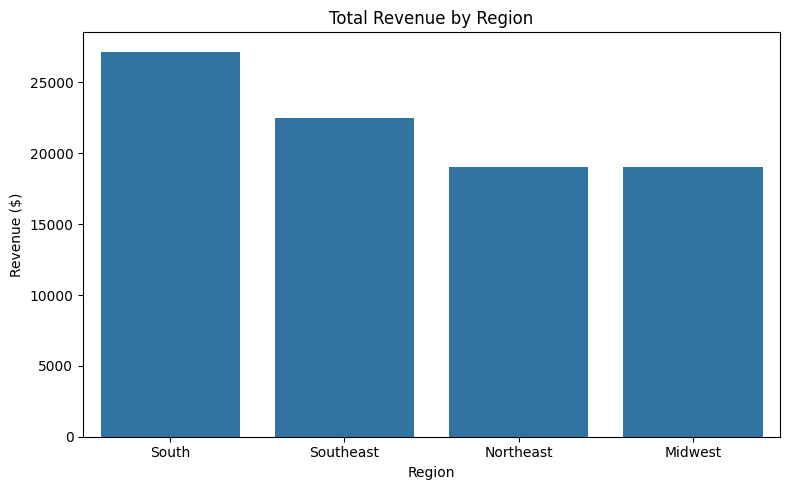

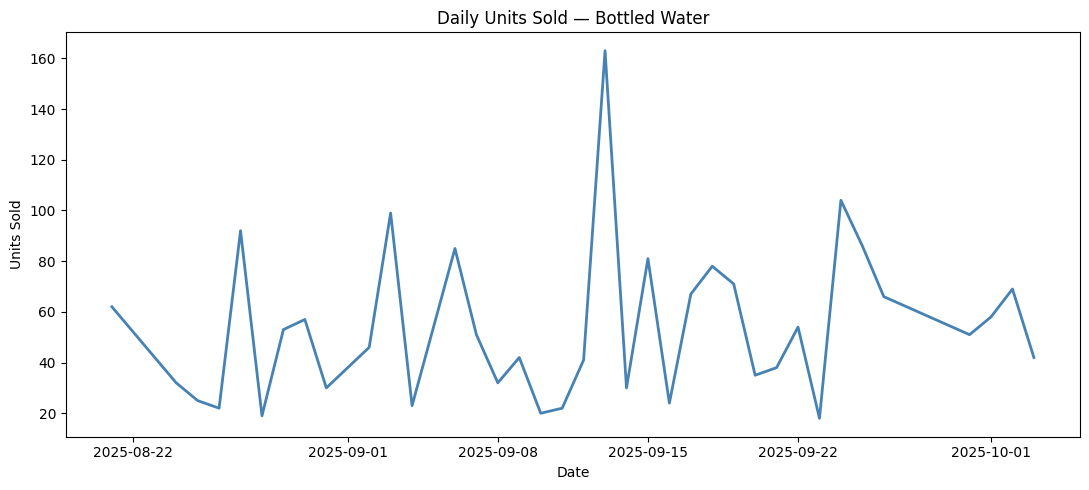

In [63]:
# Write your own code here.
# This cell is intentionally blank for student experimentation.

region_summary = df.groupby("region", as_index=False)["revenue"].sum().sort_values("revenue", ascending=False)
print(region_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=region_summary, x="region", y="revenue")
plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

#south generates the most revenue, while northeast and midwest don't generate as much



product_choice = "Bottled Water"
prod_df = df[df["product"] == product_choice]
prod_daily = prod_df.groupby("date", as_index=False)["units_sold"].sum().sort_values("date")
print(prod_daily)

plt.figure(figsize=(11, 5))
plt.plot(prod_daily["date"], prod_daily["units_sold"], color="steelblue", linewidth=2)
plt.title(f"Daily Units Sold — {product_choice}")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

#bottled water units sold fluctuate with no real trend. maybe big spikes for storm watch"

## Part 14 — Wrap-up questions

Write short answers to these:
1. Which plotting library felt easiest to use? seaborn, less code
2. Which chart type was most useful for category comparisons? bar, obvious to tell bar height
3. Which chart type was best for time-based trends? line, line showed progress over time
4. What did you learn about the relationship between data preparation and visualizaton? always need to groupby or filter data before you plot to get a meaningful chart
5. Which plot in this notebook was the most effective, and why? heatmap because it was compact and the colors immediately caught your eyes.
